In [ ]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.3 MB/s eta 0:00:00


Dataset

In [ ]:
#descarga del dataset desde roboflow para entrenar el modelo YOLOv8

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="peMPMsFAuZsh3EgR0qQZ") #api key privada de mi dataset
project = rf.workspace("claudio-fsgrc").project("animal_detection-6gnuh")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Animal_detection-2 in yolov8:: 100%|██████████| 1191/1191 [00:00<00:00, 9387.82it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Train model

In [ ]:
#entrenamiento del modelo YOLOv8 con el dataset descargado

from ultralytics import YOLO

# Cargar el modelo base pre-entrenado
model = YOLO('yolov8s.pt')

# Iniciar el entrenamiento
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    plots=True # Generará gráficas de rendimiento al final
)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Animal_detection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

Revision de overfitting

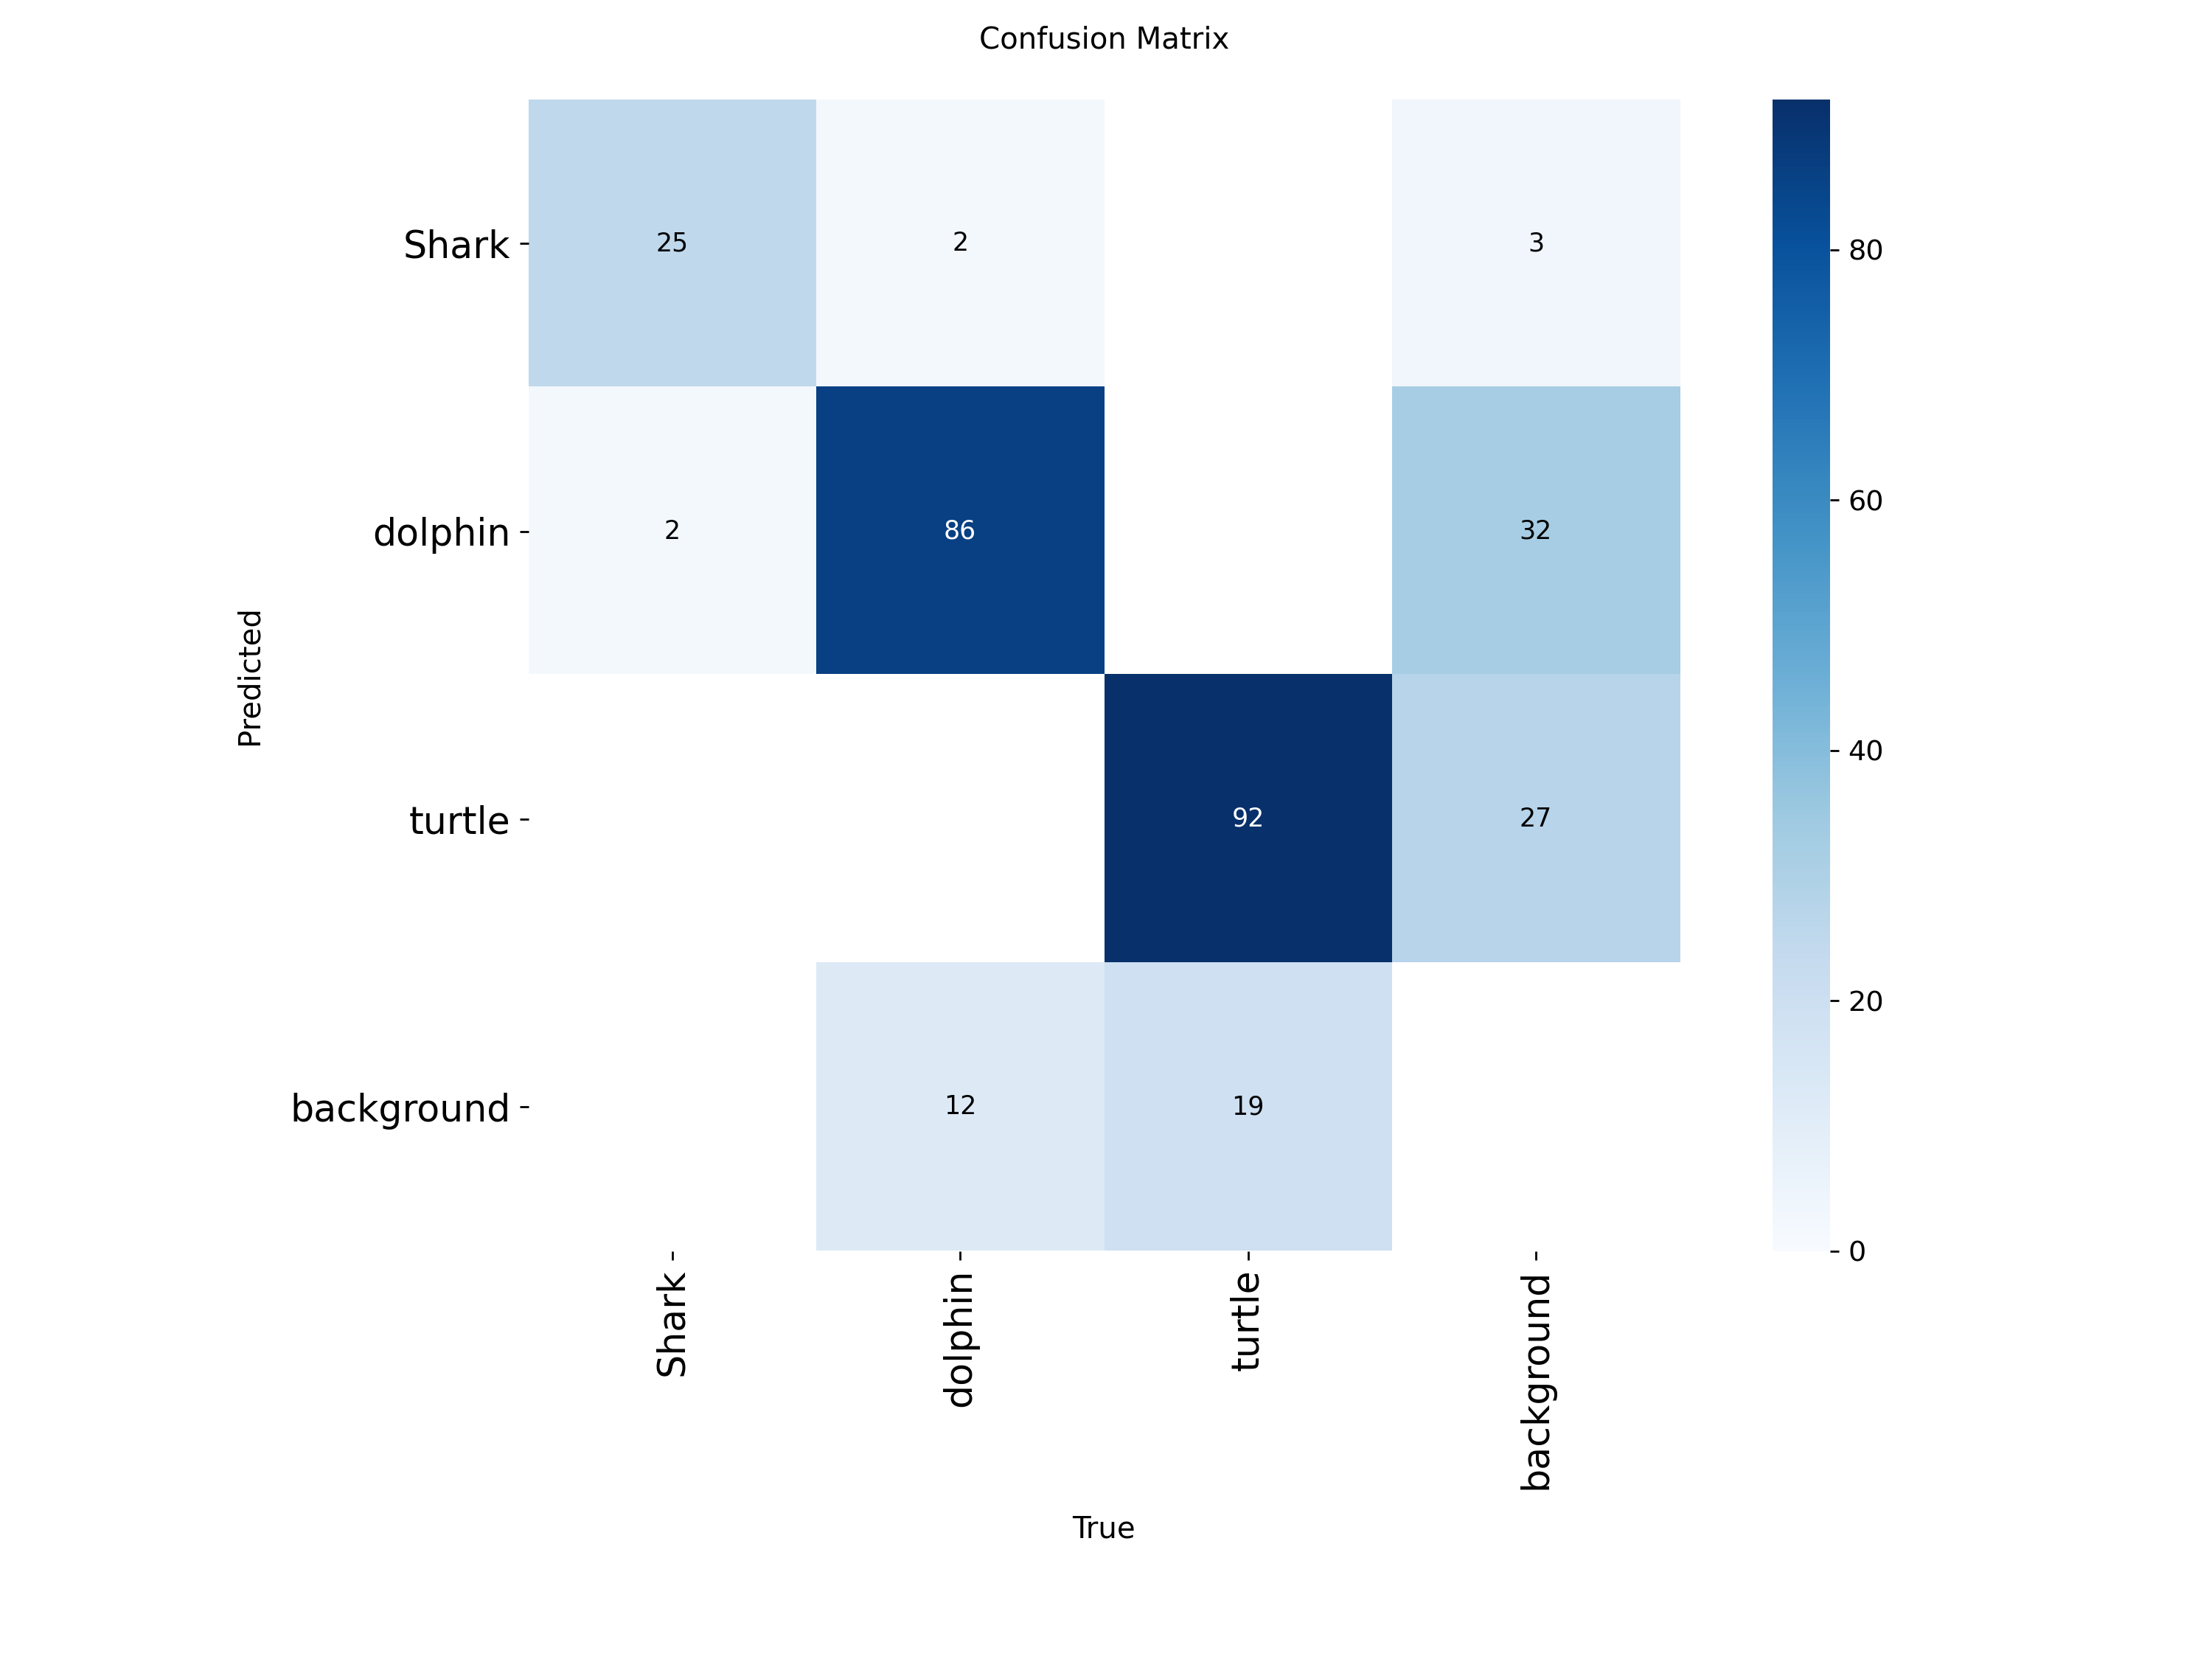

In [ ]:
#muestra de la matriz de confusion para analizar el rendimiento del modelo
import glob
from IPython.display import Image, display

# Mostrar la matriz de confusión generada durante el entrenamiento
for image_path in glob.glob('runs/detect/train/confusion_matrix.png'):
    display(Image(filename=image_path))